# Crime Category Classification - End to End Project

This notebook demonstrates a full machine learning workflow, including data preprocessing, exploratory data analysis, dimensionality reduction (PCA), model training (Logistic Regression, SVM, Decision Tree, Neural Network), evaluation, and model comparison.

## Environment Setup
Importing necessary project modules. Ensure that you have installed requirements via `pip install -r requirements.txt`.

In [1]:
import sys
import os
sys.path.append('../src')

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from data_preprocessing import load_data, clean_data, encode_features, scale_data
from visualization import plot_class_distribution, plot_correlation_heatmap, apply_and_plot_pca, plot_model_comparison
from models import train_logistic_regression, train_svm, train_decision_tree, train_neural_network
from evaluation import evaluate_model
from utils import save_sklearn_model, save_nn_model

from sklearn.model_selection import train_test_split

## 1. Data Preparation
We start by loading the data. We assume `data/train.csv` exists. If not, the function handles it gracefully.

In [2]:
# Define your dataset path
DATA_PATH = '../data/train.csv'

# Set target column name representing the crime category
TARGET_COL = 'Category'

# Load data
df = load_data(DATA_PATH)

if df is not None:
    display(df.head())
    df.info()
    display(df.describe())

Dataset successfully loaded from ../data/train.csv


,Dates,Category,Descript,DayOfWeek,PdDistrict,Resolution,Address,X,Y
0,2015-05-13 23:53:00,WARRANTS,WARRANT ARREST,Wednesday,NORTHERN,"ARREST, BOOKED",OAK ST / LAGUNA ST,-122.425892,37.774599
1,2015-05-13 23:53:00,OTHER OFFENSES,TRAFFIC VIOLATION ARREST,Wednesday,NORTHERN,"ARREST, BOOKED",OAK ST / LAGUNA ST,-122.425892,37.774599
2,2015-05-13 23:33:00,OTHER OFFENSES,TRAFFIC VIOLATION ARREST,Wednesday,NORTHERN,"ARREST, BOOKED",VANNESS AV / GREENWICH ST,-122.424363,37.800414
3,2015-05-13 23:30:00,LARCENY/THEFT,GRAND THEFT FROM LOCKED AUTO,Wednesday,NORTHERN,NONE,1500 Block of LOMBARD ST,-122.426995,37.800873
4,2015-05-13 23:30:00,LARCENY/THEFT,GRAND THEFT FROM LOCKED AUTO,Wednesday,PARK,NONE,100 Block of BRODERICK ST,-122.438738,37.771541


<class 'pandas.DataFrame'>
RangeIndex: 878049 entries, 0 to 878048
Data columns (total 9 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Dates       878049 non-null  str    
 1   Category    878049 non-null  str    
 2   Descript    878049 non-null  str    
 3   DayOfWeek   878049 non-null  str    
 4   PdDistrict  878049 non-null  str    
 5   Resolution  878049 non-null  str    
 6   Address     878049 non-null  str    
 7   X           878049 non-null  float64
 8   Y           878049 non-null  float64
dtypes: float64(2), str(7)
memory usage: 60.3 MB


,X,Y
count,878049.000000,878049.000000
mean,-122.422616,37.771020
std,0.030354,0.456893
min,-122.513642,37.707879
25%,-122.432952,37.752427
50%,-122.416420,37.775421
75%,-122.406959,37.784369
max,-120.500000,90.000000


Initial missing values:
Dates         0
Category      0
Descript      0
DayOfWeek     0
PdDistrict    0
Resolution    0
Address       0
X             0
Y             0
dtype: int64
Missing values after cleaning:
Dates         0
Category      0
Descript      0
DayOfWeek     0
PdDistrict    0
Resolution    0
Address       0
X             0
Y             0
dtype: int64


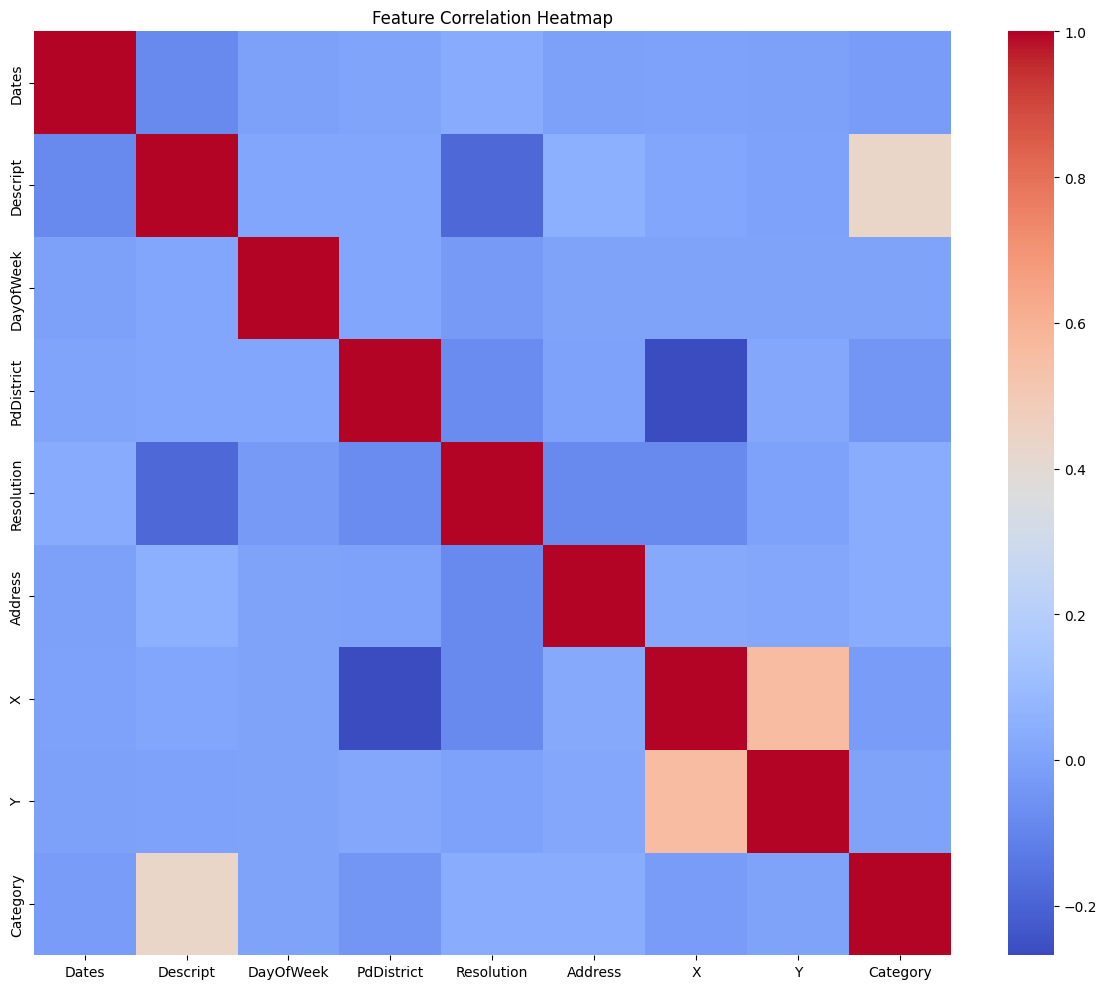

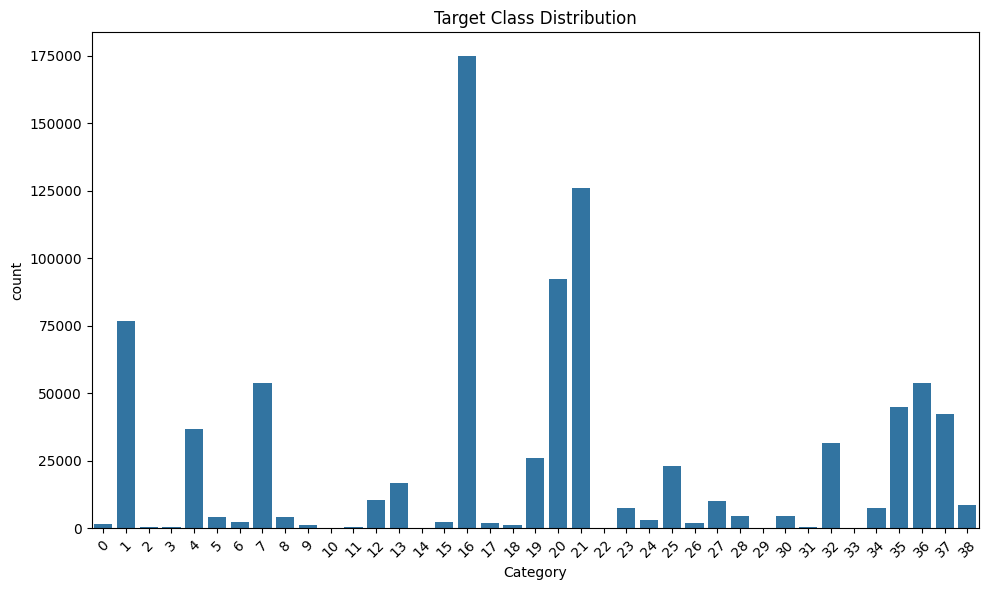

Data Preprocessing Setup Complete.


In [3]:
if df is not None:
    # Clean Data
    df = clean_data(df)
    
    # Note: If memory usage is high or text fields exist, drop text fields like 'Descript' or 'Resolution'
    # df = df.drop(columns=['Descript', 'Resolution'], errors='ignore')
    
    # Encode Categorical features
    X, y, encoders = encode_features(df, TARGET_COL)
    
    # Visualization: Heatmap
    plot_correlation_heatmap(pd.concat([X, y], axis=1), output_path='../outputs/correlation_heatmap.png')
    
    # Visualization: Target Distribution
    plot_class_distribution(y, output_path='../outputs/class_distribution.png')
    
    # Split the dataset
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Scale features
    X_train_scaled, X_test_scaled, scaler = scale_data(X_train, X_test)
    print("Data Preprocessing Setup Complete.")

## 2. Dimensionality Reduction (PCA)
Visualizing the scaled data in 2D using Principal Component Analysis.

PCA Explained Variance Ratio: [0.20356877 0.15777489]
Total Explained Variance: 0.3613


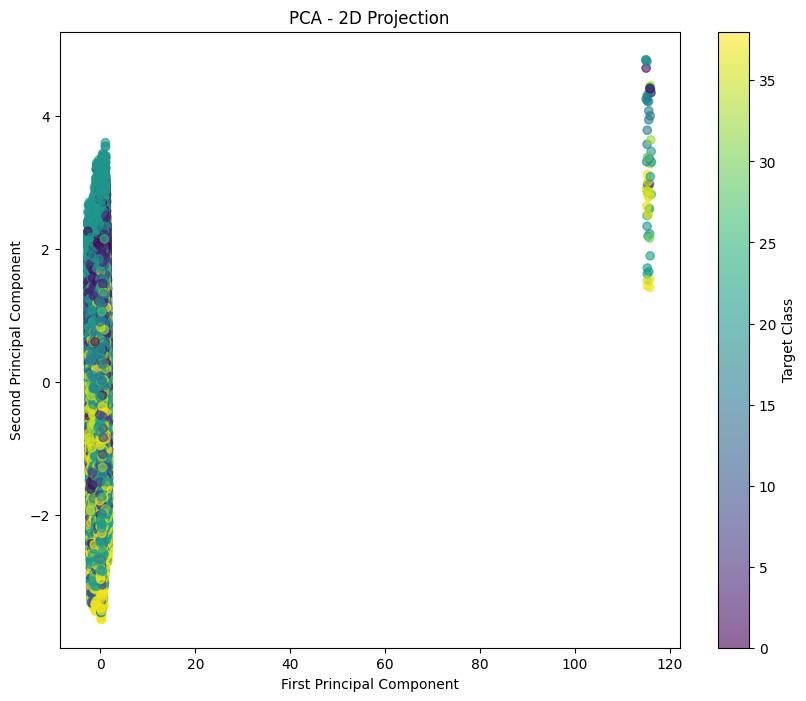

In [4]:
if df is not None:
    X_train_pca, pca_model = apply_and_plot_pca(X_train_scaled, y_train, output_path='../outputs/pca_plot.png')

## 3. Models Implementation & Evaluation
Training and evaluating multiple models, and saving them to disk.

Training Logistic Regression...

--- Evaluation for Logistic Regression ---
Accuracy: 0.3882

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       321
           1       0.38      0.26      0.31     15364
           2       0.00      0.00      0.00        72
           3       0.00      0.00      0.00        58
           4       0.20      0.14      0.17      7389
           5       0.00      0.00      0.00       828
           6       0.00      0.00      0.00       459
           7       0.31      0.26      0.28     10723
           8       0.00      0.00      0.00       857
           9       0.00      0.00      0.00       222
          10       0.00      0.00      0.00        51
          11       0.00      0.00      0.00        92
          12       0.00      0.00      0.00      2092
          13       0.00      0.00      0.00      3277
          14       0.00      0.00      0.00        33
          15      

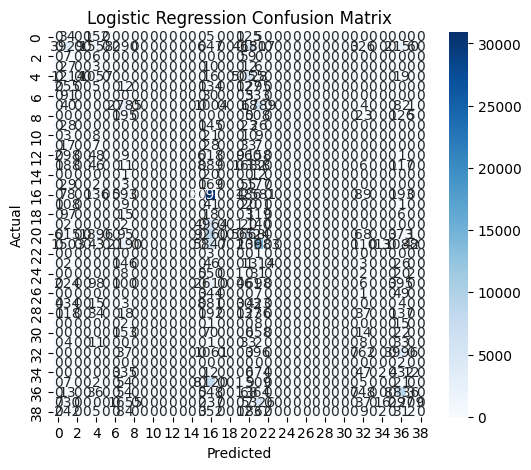

Model saved to ../models\log_reg_model.pkl


In [5]:
model_results = {}

if df is not None:
    # 1. Logistic Regression
    lr_model = train_logistic_regression(X_train_scaled, y_train)
    acc_lr = evaluate_model(lr_model, X_test_scaled, y_test, "Logistic Regression")
    model_results['Logistic Regression'] = {'accuracy': acc_lr}
    save_sklearn_model(lr_model, 'log_reg_model.pkl')

Training Decision Tree...
Best Decision Tree params: {'max_depth': None, 'min_samples_split': 2}

--- Evaluation for Decision Tree ---
Accuracy: 0.9995

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       321
           1       1.00      1.00      1.00     15364
           2       1.00      1.00      1.00        72
           3       1.00      1.00      1.00        58
           4       1.00      1.00      1.00      7389
           5       1.00      1.00      1.00       828
           6       1.00      1.00      1.00       459
           7       1.00      1.00      1.00     10723
           8       1.00      1.00      1.00       857
           9       1.00      1.00      1.00       222
          10       1.00      1.00      1.00        51
          11       1.00      0.98      0.99        92
          12       1.00      1.00      1.00      2092
          13       1.00      1.00      1.00      3277
          14 

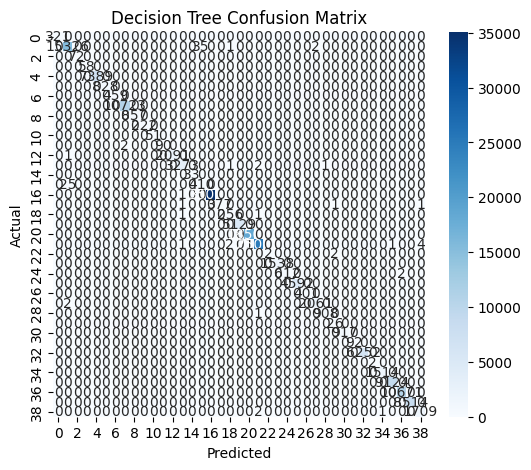

Model saved to ../models\decision_tree_model.pkl


In [6]:
if df is not None:
    # 2. Decision Tree
    dt_model = train_decision_tree(X_train_scaled, y_train)
    acc_dt = evaluate_model(dt_model, X_test_scaled, y_test, "Decision Tree")
    model_results['Decision Tree'] = {'accuracy': acc_dt}
    save_sklearn_model(dt_model, 'decision_tree_model.pkl')

Training Support Vector Machine...

--- Evaluation for SVM ---
Accuracy: 0.4458

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       321
           1       0.45      0.51      0.48     15364
           2       0.00      0.00      0.00        72
           3       0.00      0.00      0.00        58
           4       0.38      0.42      0.40      7389
           5       0.00      0.00      0.00       828
           6       0.00      0.00      0.00       459
           7       0.44      0.68      0.53     10723
           8       0.00      0.00      0.00       857
           9       0.00      0.00      0.00       222
          10       0.00      0.00      0.00        51
          11       0.00      0.00      0.00        92
          12       0.00      0.00      0.00      2092
          13       0.04      0.01      0.01      3277
          14       0.00      0.00      0.00        33
          15       0.00      0.

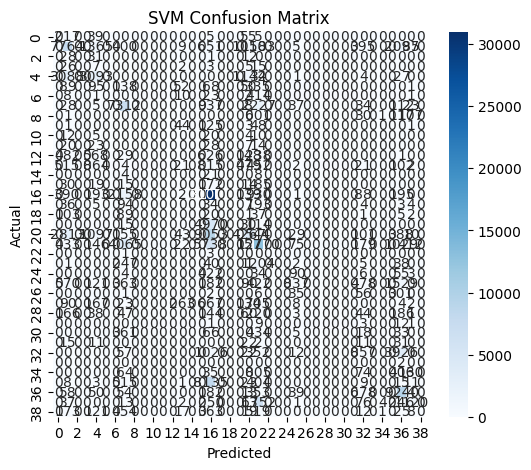

Model saved to ../models\svm_model.pkl


In [7]:
if df is not None:
    # 3. Support Vector Machine
    # SVM can be extremely slow on large datasets, consider sampling X_train_scaled if needed
    svm_model = train_svm(X_train_scaled[:5000], y_train[:5000]) # Training on a subset for speed
    acc_svm = evaluate_model(svm_model, X_test_scaled, y_test, "SVM")
    model_results['SVM'] = {'accuracy': acc_svm}
    save_sklearn_model(svm_model, 'svm_model.pkl')

Training Neural Network...
Epoch 1/50
17561/17561 ━━━━━━━━━━━━━━━━━━━━ 33s 2ms/step - accuracy: 0.5572 - loss: 1.4499 - val_accuracy: 0.6751 - val_loss: 1.0590
Epoch 2/50
17561/17561 ━━━━━━━━━━━━━━━━━━━━ 31s 2ms/step - accuracy: 0.6834 - loss: 1.0567 - val_accuracy: 0.7364 - val_loss: 0.8783
Epoch 3/50
17561/17561 ━━━━━━━━━━━━━━━━━━━━ 31s 2ms/step - accuracy: 0.7279 - loss: 0.9227 - val_accuracy: 0.7570 - val_loss: 0.8014
Epoch 4/50
17561/17561 ━━━━━━━━━━━━━━━━━━━━ 33s 2ms/step - accuracy: 0.7460 - loss: 0.8587 - val_accuracy: 0.7495 - val_loss: 0.8179
Epoch 5/50
17561/17561 ━━━━━━━━━━━━━━━━━━━━ 35s 2ms/step - accuracy: 0.7574 - loss: 0.8196 - val_accuracy: 0.7613 - val_loss: 0.7974
Epoch 6/50
17561/17561 ━━━━━━━━━━━━━━━━━━━━ 35s 2ms/step - accuracy: 0.7657 - loss: 0.7883 - val_accuracy: 0.7696 - val_loss: 0.7605
Epoch 7/50
17561/17561 ━━━━━━━━━━━━━━━━━━━━ 35s 2ms/step - accuracy: 0.7709 - loss: 0.7669 - val_accuracy: 0.7662 - val_loss: 0.7438
Epoch 8/50
17561/17561 ━━━━━━━━━━━━━━━━━━━

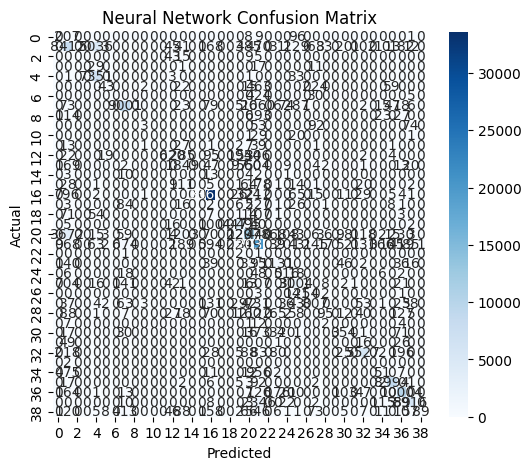

Neural Network model saved to ../models\nn_model.h5


In [8]:
if df is not None:
    # 4. Neural Network
    num_classes = len(np.unique(y))
    nn_model = train_neural_network(X_train_scaled, y_train, output_classes=num_classes)
    acc_nn = evaluate_model(nn_model, X_test_scaled, y_test, "Neural Network", is_nn=True)
    model_results['Neural Network'] = {'accuracy': acc_nn}
    save_nn_model(nn_model, 'nn_model.h5')

## 4. Model Comparison
Let's compare the results.

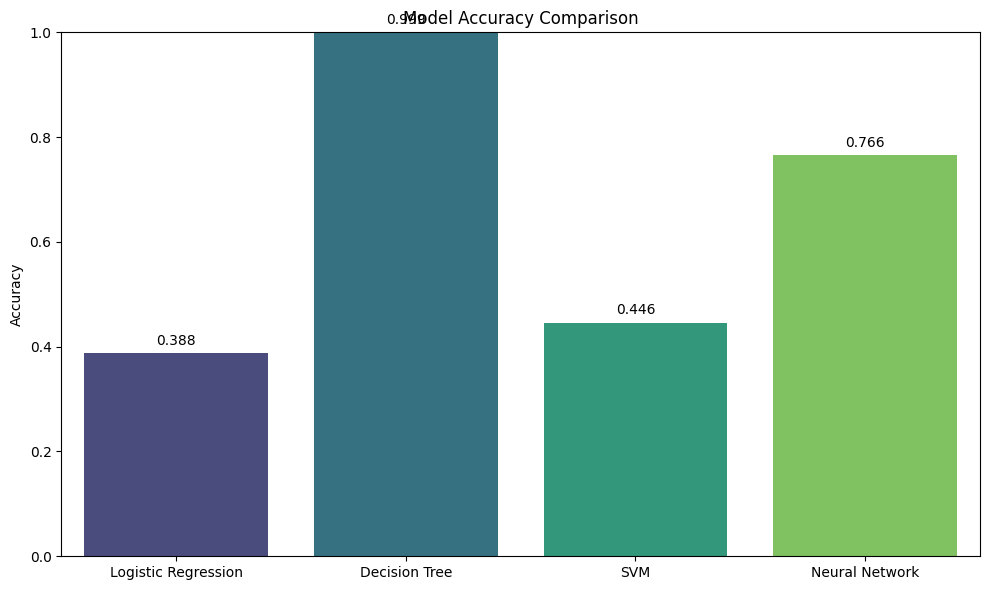

In [9]:
if df is not None:
    plot_model_comparison(model_results, output_path='../outputs/model_comparison.png')

## Conclusion
In this notebook, we performed an end-to-end classification task:
* Cleaned missing data and preprocessed categorical fields.
* Implemented standard scaling and checked variance via PCA.
* Tested four different classification algorithms:
  * Logistic Regression
  * Decision Trees
  * Support Vector Machine
  * Artificial Neural Network

All output artifacts (plots) have been saved to `outputs/` and models to `models/`.